In [1]:
import pandas as pd

df = pd.read_csv("../data/reviews_clean.csv")
print("Loaded:", df.shape)
df.head()

Loaded: (22498, 3)


,text,stars,label
0,Not the best way to make a meatloaf. I did not...,3.0,0
1,Chicken was awesome. Collards very good. Skip ...,4.0,0
2,"Best cheese steak in all of Philly, probably t...",5.0,1
3,Unbelievable to me that the hotel allows us to...,1.0,0
4,"This is a great little place! Gyros, Greek sal...",5.0,0


In [2]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

print("NLTK data downloaded!")

NLTK data downloaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sarthak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sarthak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Load English stopwords — words like "the", "is", "and"
stop_words = set(stopwords.words('english'))

# Stemmer — cuts words to their root form
stemmer = PorterStemmer()

def clean_text(text):
    # Step 1: lowercase everything
    text = text.lower()
    
    # Step 2: remove everything except letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 3: split into individual words
    words = text.split()
    
    # Step 4: remove stopwords AND stem each word
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    
    # Step 5: join back into a single string
    return ' '.join(words)

# Test it on one sentence first
test = "The food was absolutely AMAZING!!! I will definitely come back again."
print("Before:", test)
print("After: ", clean_text(test))

Before: The food was absolutely AMAZING!!! I will definitely come back again.
After:  food absolut amaz definit come back


In [4]:
print("Cleaning reviews... this takes 2-3 minutes")

df['clean_text'] = df['text'].apply(clean_text)

print("Done!")
print("\nOriginal:", df['text'].iloc[0][:100])
print("Cleaned: ", df['clean_text'].iloc[0][:100])

Cleaning reviews... this takes 2-3 minutes
Done!

Original: Not the best way to make a meatloaf. I did not enjoy the use of sausage. It didn't even taste like a
Cleaned:  best way make meatloaf enjoy use sausag didnt even tast like meatloaf get mash potato delici spot to


In [5]:
df.to_csv("../data/reviews_preprocessed.csv", index=False)
print("Saved preprocessed data!", df.shape)

Saved preprocessed data! (22498, 4)


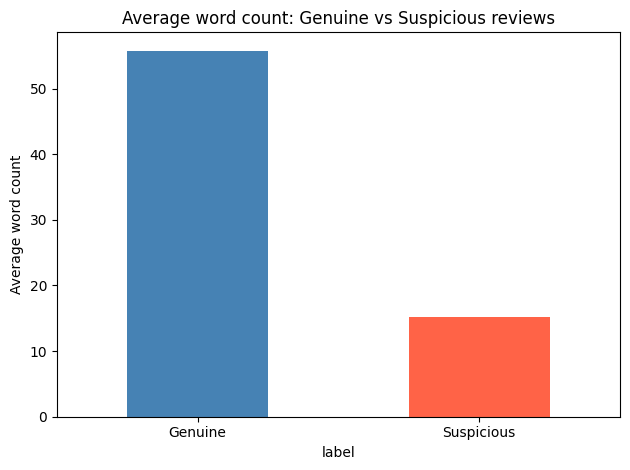

Chart saved!


In [6]:
import matplotlib.pyplot as plt

# Review length distribution
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

df.groupby('label')['review_length'].mean().plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    title='Average word count: Genuine vs Suspicious reviews'
)
plt.xticks([0, 1], ['Genuine', 'Suspicious'], rotation=0)
plt.ylabel('Average word count')
plt.tight_layout()
plt.savefig("../data/review_length_chart.png")
plt.show()
print("Chart saved!")